In [1]:
import os
import json
from tqdm import tqdm

import numpy as np

os.environ["JAX_PLATFORMS"] = "cpu"
import jax.numpy as jnp
import matplotlib.pyplot as plt

from utils import load_pass_curves, threshold_to_profit_batch, cost_for_pass

In [2]:
base_dir = "../data/swebench/distill"

results = {}
for file in os.listdir(base_dir):
    if not file.endswith(".jsonl"):
        continue

    model_name = file.split(".jsonl")[0]
    data = [json.loads(line) for line in open(os.path.join(base_dir, file), "r")]
    results[model_name] = data

Compute pass at budget and pass at k.

In [3]:
models1b = ['1.7b-84', '1.7b-281', '1.7b-845', '1.7b-2816', '1.7b-1e']

budget_grid = np.logspace(np.log10(1e-4), np.log10(1), 250)
budget_grid_k = np.arange(1, 100)

pass_curves = load_pass_curves(results, models1b + ['qwen3-coder-480b'], budget_grid)
pass_curvesk = load_pass_curves(results, models1b, budget_grid_k, cost_per_problem_override=1)

In [4]:
# we evaluate profit from 5% solve rate to frontier solve rate
max_perf = pass_curves.mean(axis=0).max()
performance_grid = jnp.linspace(max_perf-0.1, max_perf, 100)

# grid of compute allocations
compute_first = np.r_[0, np.logspace(np.log10(0.001), np.log10(0.15), 100), 1]
compute_second = 1 - compute_first
compute_allocation = np.stack([compute_first, compute_second], axis=-1)

Calculate the profit opportunities created when pairing each distilled model with Qwen Coder 30B

In [5]:
# calculate the max profit 
profits1b = []
for i in tqdm(range(len(models1b))):
    profit_grid = threshold_to_profit_batch(
        budget_grid,
        pass_curves[:, [i, -1]],
        compute_allocation,
        performance_grid,
    ).mean(axis=-1)
    max_profit = profit_grid.max()
    profits1b.append(max_profit)

100%|██████████| 5/5 [00:04<00:00,  1.09it/s]


In [6]:
# plot performance vs cost...
performance_grid_plot = np.linspace(0.05, max_perf, 100)
provider_prices_plot = np.array([
    cost_for_pass(budget_grid, p, performance_grid_plot)
    for p in pass_curves.mean(axis=0)
])

/tmp/ipykernel_1299501/22023677.py:45: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  ax.plot(


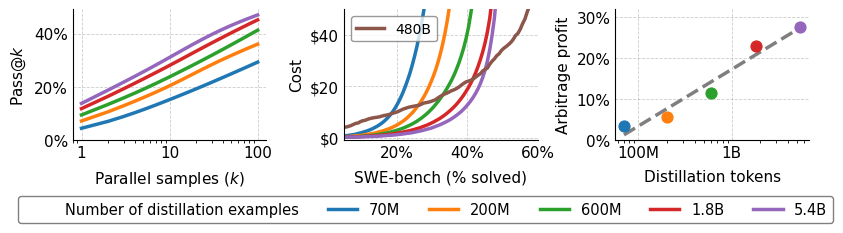

In [7]:
from matplotlib.ticker import FuncFormatter
import seaborn as sns
palette = sns.color_palette()

fig, axs = plt.subplots(1, 3, figsize=(9.5, 1.7))

labels = {
    '1.7b-84': '70M',
    '1.7b-281': '200M',
    '1.7b-845': '600M',
    '1.7b-2816': '1.8B',
    '1.7b-1e': '5.4B'
}

def format_ax(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)

    ax.grid(alpha=0.4, linewidth=0.6, linestyle="--", color="gray", zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(labelsize=11, direction="out", length=0, width=0.8)

ax = axs[0]
for i, model in enumerate(models1b):
    passk = pass_curvesk[:, i].mean(axis=0)
    ax.plot(budget_grid_k, passk, linewidth=2.5, label=labels[model], color=palette[i])
ax.set_xscale("log")

ax = axs[1]

for i in range(provider_prices_plot.shape[0]):
    ax.plot(performance_grid_plot, provider_prices_plot[i]*500, linewidth=2.5, color=palette[i])
ax.set_ylim(-1, 100)
ax.set_xlim(0.05, max_perf)

ax = axs[2]
steps = np.array([84, 281, 845, 2816, 2816*3])
examples = 400000 * steps / steps[-1]
examples = np.array([70e6, 200e6, 600e6, 1.8e9, 5.4e9])
y = profits1b

for i, (xx, yy) in enumerate(zip(examples, y)):
    ax.plot(
        xx,
        yy,
        'o',
        marker='o',
        linestyle='',
        markersize=8,
        linewidth=2.5,
        markeredgewidth=0.8,
        color=palette[i]
    )

a, b = np.polyfit(np.log(examples), y, 1)
xx = np.logspace(np.log10(examples[0]), np.log10(examples[-1]), 100)
yy = a * np.log(xx) + b
plt.plot(xx, yy, linestyle='--', linewidth=2.5, zorder=-1, markersize=0, color=palette[-3])
plt.xscale('log')

for ax in axs:
    format_ax(ax)

fig.subplots_adjust(wspace=0.3)

axs[0].set_xlabel("Parallel samples ($k$)", fontsize=11, fontweight="normal", labelpad=7)
axs[0].set_ylabel("Pass@$k$", fontsize=11, fontweight="normal", labelpad=4)

axs[1].set_xlabel("SWE-bench (% solved)", fontsize=11, fontweight="normal", labelpad=7)
axs[1].set_ylabel("Cost", fontsize=11, fontweight="normal", labelpad=4)
axs[2].set_xlabel("Distillation tokens", fontsize=11, fontweight="normal", labelpad=7)
axs[2].set_ylabel("Arbitrage profit", fontsize=11, fontweight="normal", labelpad=4)

# set tick labels of y 0
axs[0].set_xticks([1, 10, 100])
axs[0].set_xticklabels(['1', '10', '100'])
axs[2].set_xticks([1e8, 1e9])
axs[2].set_xticklabels(['100M', '1B'])
axs[2].yaxis.set_major_formatter(FuncFormatter(lambda x, p: f"{x*100:.0f}%"))

axs[0].yaxis.set_major_formatter(FuncFormatter(lambda x, p: f"{x*100:.0f}%"))
axs[1].yaxis.set_major_formatter(FuncFormatter(lambda x, p: f"${x:.0f}"))
axs[1].xaxis.set_major_formatter(FuncFormatter(lambda x, p: f"{x*100:.0f}%"))

from matplotlib.lines import Line2D

legend_elements = []

for i, model in enumerate(list(labels.keys())[::-1]):
    legend_elements.append(Line2D([0], [0], color=palette[4-i], linewidth=2.5, label=labels[model]))
legend_elements = legend_elements[::-1]

first_entry = Line2D([0], [0], color=palette[0], linewidth=0, label='Number of distillation examples')
legend_elements.insert(0, first_entry)

fig.legend(
    handles=legend_elements,
    loc="lower left",
    ncol=6,
    fontsize=10.5,
    framealpha=1.0,
    edgecolor="gray",
    fancybox=True,
    frameon=True,
    labelspacing=0.4,
    bbox_to_anchor=(0.06, -0.42),
)

# separate the plots a bit more
fig.subplots_adjust(wspace=0.4)
# axs[1].set_yscale("log")

axs[0].set_ylim(0, None)
axs[1].set_ylim(None, 50)
axs[1].set_xlim(None, 0.6)
axs[2].set_ylim(None, 0.32)

# one single legend element with Qwen 3 Coder 480B and its color
legend_elements = [
    Line2D([0], [0], color=palette[5], linewidth=2.5, label='480B'),
]
axs[1].legend(
    handles=legend_elements,
    loc="best",
    ncol=1,
    edgecolor="gray",
    fancybox=True,
    frameon=True,
    labelspacing=0.4,
)

plt.savefig(f"plots/scale-plot.pdf", bbox_inches="tight")